# Статистический анализ данных сервиса аренды самокатов GoFast

Перед нами стоит задача по анализу данных о пользователях из нескольких городов, которые пользуются услугами по аренде самокатов. 

Чтобы совершать поездки по городу, пользователи сервиса GoFast пользуются мобильным приложением. 
Сервисом можно пользоваться:
* без подписки 
    абонентская плата отсутствует;
    стоимость одной минуты поездки — 8 рублей;
    стоимость старта (начала поездки) — 50 рублей;
* с подпиской Ultra 
    абонентская плата — 199 рублей в месяц;
    стоимость одной минуты поездки — 6 рублей;
    стоимость старта — бесплатно.
    
Цель: провести несколько A/B тестов, а именно:

* Пользователи с подпиской тратят в среднем больше времени на поездки, чем пользователи без подписки.
* Пользователи в среднем преодолевают меньше 3130 метров.
* Помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки.
* Количество обращений в техподдержку значимо снизилось после обновления сервера приложения.

Также, дополнительно, нужно:
* подобрать параметры распределения, построить график и расcчитать минимальное количество промокодов, которые нужно разослать во время маркетинговой акции, чтобы с 95% вероятность выполнить плановые показатели;
* построить примерный график распределения с помощью аппроксимации push-уведомлений, которые рассылаются пользователям, и оценить вероятность, что уведомление откроет лишь определенное количество пользователей.


###### Ход исследования

Дано:

/datasets/users_go.csv (данные о пользователях), 
/datasets/rides_go.csv (данные о поездках),
/datasets/subscriptions_go.csv (данные о подписках)

Алгоритм действий:

* Обзор данных.
* Предобработка данных.
* Исследовательский анализ данных
* Объединение и структурирование данных
* Подсчет выручки сервисом
* Проверка гипотез.
* Построение ряда распределений.

/Тезисно/ 

Мы посмотрим что за данные у нас имеются и в каком они состоянии (есть ли пропуски, дубли, верно ли питон понял тип данных), затем обработаем, верятно, сделаем дополнительные критерии чтобы потом разбивать данные на группы для проведения стат вычислений и посмотрим их на графиках, чтобы понять сколько и чего мы имеем, что от чего зависит. После этого приступим с статистическим тестам и предсказаниям данных о промокодах и пуш уведомлениях.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats as st

# Шаг 1. Загрузка данных

In [2]:
users = pd.read_csv('/datasets/users_go.csv')
rides = pd.read_csv('/datasets/rides_go.csv')
subscriptions_go = pd.read_csv('/datasets/subscriptions_go.csv')

In [3]:
# сделаем функцию для знакомства с датафреймами
def check_df(df):

    # общая информация 
    display(df.info())

    # первые 5 строк
    display(df.head())

In [4]:
check_df(users)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1565 entries, 0 to 1564
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            1565 non-null   int64 
 1   name               1565 non-null   object
 2   age                1565 non-null   int64 
 3   city               1565 non-null   object
 4   subscription_type  1565 non-null   object
dtypes: int64(2), object(3)
memory usage: 61.3+ KB


None

,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra


user_id — уникальный идентификатор пользователя;

name — имя пользователя;

age — возраст;

city — город;

subscription_type — тип подписки (free, ultra).


In [5]:
check_df(rides)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   user_id   18068 non-null  int64  
 1   distance  18068 non-null  float64
 2   duration  18068 non-null  float64
 3   date      18068 non-null  object 
dtypes: float64(2), int64(1), object(1)
memory usage: 564.8+ KB


None

,user_id,distance,duration,date
0,1,4409.919140,25.599769,2021-01-01
1,1,2617.592153,15.816871,2021-01-18
2,1,754.159807,6.232113,2021-04-20
3,1,2694.783254,18.511000,2021-08-11
4,1,4028.687306,26.265803,2021-08-28


user_id — уникальный идентификатор пользователя;

distance — расстояние, которое пользователь проехал в текущей сессии (в метрах);

duration — продолжительность сессии (в минутах) — время с того момента, как пользователь нажал кнопку «Начать поездку» до момента, как он нажал кнопку «Завершить поездку»;

date — дата совершения поездки.

In [6]:
check_df(subscriptions_go)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   subscription_type  2 non-null      object
 1   minute_price       2 non-null      int64 
 2   start_ride_price   2 non-null      int64 
 3   subscription_fee   2 non-null      int64 
dtypes: int64(3), object(1)
memory usage: 192.0+ bytes


None

,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199


subscription_type — тип подписки;

minute_price — стоимость одной минуты поездки по данной подписке;

start_ride_price — стоимость начала поездки;

subscription_fee — стоимость ежемесячного платежа.


В таблице rides не верно определен тип данных колонки date, необходимо изменить тип.
Связующим ключом таблиц с поездками и пользователми является колонка 'user_id'.
В таблице с пользователями колонка 'subscription_type' связана с таблицей subscriptions_go.

# Шаг 2. Предобработка данных

In [7]:
rides.head(1)

,user_id,distance,duration,date
0,1,4409.91914,25.599769,2021-01-01


In [8]:
rides['date'] = pd.to_datetime(rides['date'])
rides.dtypes #тип данных изменен

user_id              int64
distance           float64
duration           float64
date        datetime64[ns]
dtype: object

In [9]:
rides['date'].dt.year.unique()

array([2021])

*сверяем чтобы был один год, иначе у нас может получиться два января за 2022 и 2021 год с одним обозначением и потом наши выводу будут неверны

In [10]:
rides['month'] = rides['date'].dt.month
rides.head(1) #добавили колонку с месяцем

,user_id,distance,duration,date,month
0,1,4409.91914,25.599769,2021-01-01,1


In [11]:
users.isna().sum()

user_id              0
name                 0
age                  0
city                 0
subscription_type    0
dtype: int64

In [12]:
users.duplicated().sum() #есть дубликаты - удаляем

31

In [13]:
users = users.drop_duplicates(keep='first').reset_index(drop=True)
users.duplicated().sum() #сработало, дубли убраны

0

In [14]:
rides.isna().sum()

user_id     0
distance    0
duration    0
date        0
month       0
dtype: int64

In [15]:
rides.duplicated().sum()

0

In [16]:
subscriptions_go.isna().sum()

subscription_type    0
minute_price         0
start_ride_price     0
subscription_fee     0
dtype: int64

In [17]:
subscriptions_go.duplicated().sum()

0

Данные обработаны - убраны дубли, проверено что больше нигде их нет, добавлена информация о месяцах и теперь можно приступать к этапу исследования данных.

# Шаг 3. Исследовательский анализ данных

In [18]:
users.columns

Index(['user_id', 'name', 'age', 'city', 'subscription_type'], dtype='object')

In [19]:
users['city'].value_counts()

Пятигорск         219
Екатеринбург      204
Ростов-на-Дону    198
Краснодар         193
Сочи              189
Омск              183
Тюмень            180
Москва            168
Name: city, dtype: int64

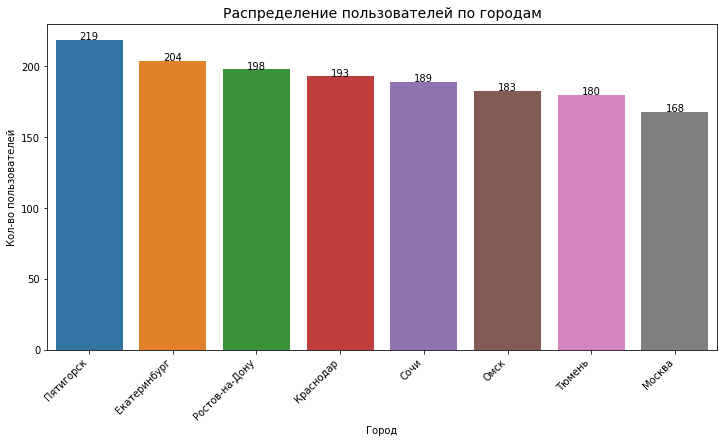

In [20]:
plt.figure(figsize=(12, 6))
sns.countplot(x='city', data=users, order=users['city'].value_counts().index)
plt.title('Распределение пользователей по городам', fontsize=14)
plt.xlabel('Город', fontsize=10)
plt.ylabel('Кол-во пользователей', fontsize=10)

# Добавление подписей
for i, (city, value) in enumerate(users['city'].value_counts().items()):
    plt.text(i, value, f'{value}', ha='center', fontsize=10) 

plt.xticks(rotation=45, ha='right', fontsize=10) #для удобного восприятия повернем
plt.yticks(fontsize=10)
plt.show()

* больше всего пользователей в Пятигорске;
* меньше всего в Москве.

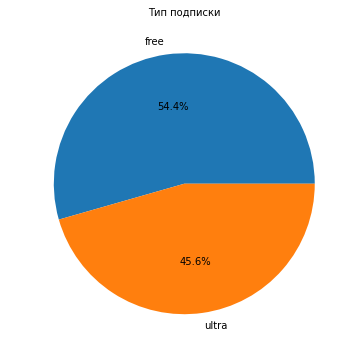

In [21]:
users['subscription_type'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(6, 6))
plt.title('Тип подписки', fontsize=10)
plt.ylabel(" ")
plt.show()

* 45.6% пользователей используют платную подписку
* 54.4% пользователей пользуются сервисом без платной подписки

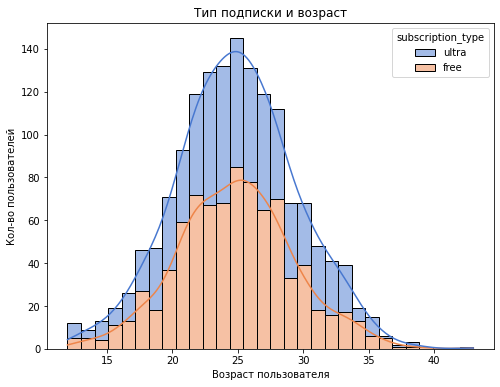

In [22]:
plt.figure(figsize=(8, 6))
sns.histplot(users, x='age', hue='subscription_type', multiple='stack', bins=30, kde=True, palette='muted')
plt.title('Тип подписки и возраст')
plt.xlabel('Возраст пользователя')
plt.ylabel('Кол-во пользователей')
plt.show()

* распределение пользователей с подпиской и без не имеют явных отличий

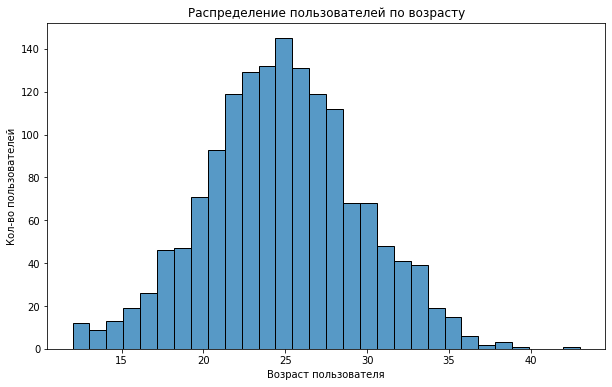

In [23]:
plt.figure(figsize=(10, 6))
sns.histplot(users, x='age', bins=30)
plt.title('Распределение пользователей по возрасту')
plt.xlabel('Возраст пользователя')
plt.ylabel('Кол-во пользователей')
plt.show()

* основной возрастной диапазон пользователей 20-30 лет

In [24]:
rides.head(1)

,user_id,distance,duration,date,month
0,1,4409.91914,25.599769,2021-01-01,1


In [25]:
rides['distance'].describe()

count    18068.000000
mean      3070.659976
std       1116.831209
min          0.855683
25%       2543.226360
50%       3133.609994
75%       3776.222735
max       7211.007745
Name: distance, dtype: float64

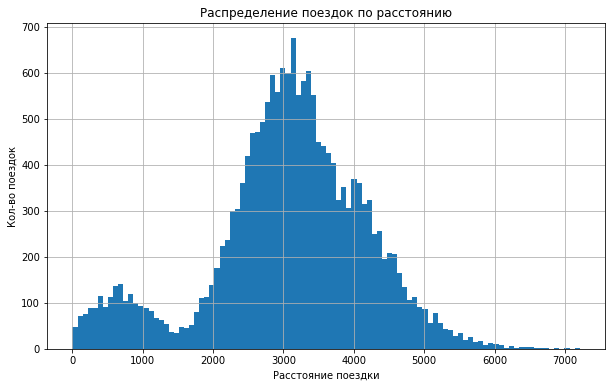

In [26]:
rides['distance'].hist(bins=100, figsize=(10, 6))
plt.title('Распределение поездок по расстоянию')
plt.xlabel('Расстояние поездки')
plt.ylabel('Кол-во поездок')
plt.show()

* от 2.5 до 4 км в основном проезжают пользователи за одну поездку.
* график имеет пик в районе поездок по 500 метров (или странную яму в промежутке от 1 км до 2 км), это требует изучения дополнительно, хоть таких поездок и мало, сейчас можем предположить что это какие-нибудь тестовые поездки или поездки по паркам или каким-то развлекательным целям, надо изучить в каком городе это происходит и какой возраст пользователей.

In [27]:
rides['duration'].describe()

count    18068.000000
mean        17.805011
std          6.091051
min          0.500000
25%         13.597563
50%         17.678395
75%         21.724800
max         40.823963
Name: duration, dtype: float64

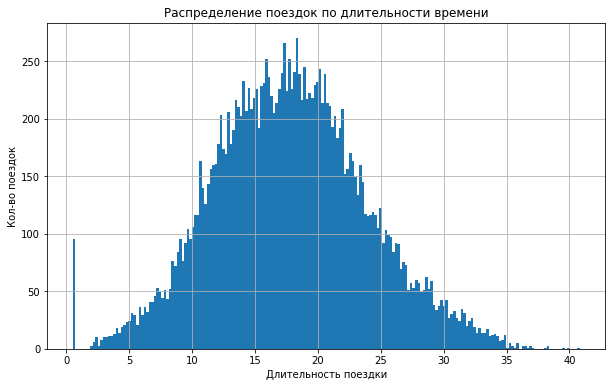

In [28]:
rides['duration'].hist(bins=200, figsize=(10, 6))
plt.title('Распределение поездок по длительности времени')
plt.xlabel('Длительность поездки')
plt.ylabel('Кол-во поездок')
plt.show()

* от 13 до 23 минут длилась большинство поездок
* видим большое количество поездок, которые сразу завершились - очень похоже на проблему, которую надо изучать дополнительно

In [29]:
rides['duration'][rides['duration'] <= 0.5].count() #считаем сколько у нас супербыстрых поездок

95

In [30]:
rides[rides['duration'] == 0.5].sort_values('distance')

,user_id,distance,duration,date,month
15132,1325,4030.308008,0.5,2021-12-22,12
17909,1524,4103.998874,0.5,2021-06-18,6
10692,1006,4106.278268,0.5,2021-10-31,10
9698,937,4169.066800,0.5,2021-12-12,12
14342,1268,4177.139336,0.5,2021-06-09,6
...,...,...,...,...,...
14574,1285,6316.574814,0.5,2021-09-25,9
13701,1224,6414.516026,0.5,2021-07-15,7
11385,1057,6601.197575,0.5,2021-02-07,2
17242,1477,6724.932981,0.5,2021-01-12,1


Данные, вероятно, ошибочные и не являются корректными тк при столь маленьком промежутке времени показывают слишком большое расстояние поездки

In [31]:
rides = rides[rides['duration'] != 0.5] #Исключаем из выборки

Мы завершили этап исследовательского анализа, выводы и комментарии отразили прямо под графиками для удобного их понимания, резюмируя:
* мы посчитали аномальными значия поездок, которые длились слишком мало времении и исключили их из датафрейма, тем более их очень маленькое количество
* 45.6% пользователей используют платную подписку
* 54.4% пользователей пользуются сервисом без платной подписки
* распределение пользователей с подпиской и без не имеют явных отличий
* основной возрастной диапазон пользователей 20-30 лет
* от 2.5 до 4 км в основном проезжают пользователи за одну поездку
* от 13 до 23 минут длилась большинство поездок

# Шаг 4. Объединение данных

In [32]:
print('Размер users:', users.shape)
print('Размер rides:', rides.shape)
print('Размер subscriptions_go:', subscriptions_go.shape)

Размер users: (1534, 5)
Размер rides: (17973, 5)
Размер subscriptions_go: (2, 4)


In [33]:
full = pd.merge(rides, users, on='user_id')
full = pd.merge(full, subscriptions_go, on='subscription_type')
full.head()

,user_id,distance,duration,date,month,name,age,city,subscription_type,minute_price,start_ride_price,subscription_fee
0,1,4409.919140,25.599769,2021-01-01,1,Кира,22,Тюмень,ultra,6,0,199
1,1,2617.592153,15.816871,2021-01-18,1,Кира,22,Тюмень,ultra,6,0,199
2,1,754.159807,6.232113,2021-04-20,4,Кира,22,Тюмень,ultra,6,0,199
3,1,2694.783254,18.511000,2021-08-11,8,Кира,22,Тюмень,ultra,6,0,199
4,1,4028.687306,26.265803,2021-08-28,8,Кира,22,Тюмень,ultra,6,0,199


In [34]:
print('Размер после объединения:', full.shape) #Ничего не потерялось, количество строк совпало

Размер после объединения: (17973, 12)


In [35]:
ultra = full[full['subscription_type'] == 'ultra']
free = full[full['subscription_type'] == 'free']

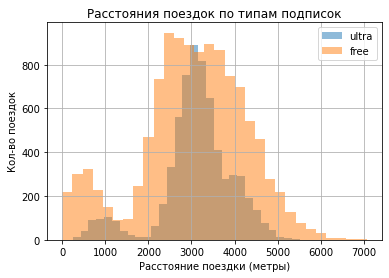

In [36]:
ultra['distance'].hist(bins=30, label = 'ultra', alpha=0.5)    
free['distance'].hist(bins=30, label = 'free', alpha=0.5)   
plt.title('Расстояния поездок по типам подписок')
plt.xlabel('Расстояние поездки (метры)')
plt.ylabel('Кол-во поездок')
plt.legend()
plt.show()

* пользователи с платной подпиской чаще проезжают меньшее расстояние за поездку, чем пользователи с без платной подписки
* у пользователей с планой подпиской очень мало поездок 1800-2000 метров, возможно, есть какие-то проблемы в этом - нужно изучать

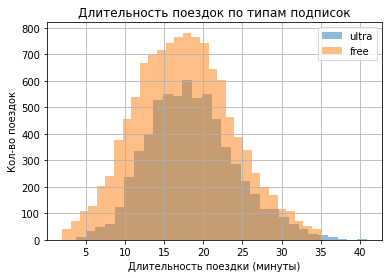

In [37]:
ultra['duration'].hist(bins=30, label = 'ultra', alpha=0.5)    
free['duration'].hist(bins=30, label = 'free', alpha=0.5)
plt.title('Длительность поездок по типам подписок')
plt.xlabel('Длительность поездки (минуты)')
plt.ylabel('Кол-во поездок')
plt.legend()
plt.show()

* время поездки у пользователей с платной подпиской чуть выше, чем у тех, то платной подпиской не пользуется
* у пользователей без платной подписки есть очень короткие поездки, которых нет у пользователей из другой группы подписки

Данные объединили, теперь информация о пользователях и их поездках и тарифах собраны в одной таблице. Также мы сравнили время длительность поездок как по расстоянию так и по времени между пользователями с платной подпиской и без нее. 

# Шаг 5. Подсчёт выручки

In [38]:
full['duration'] = np.ceil(full['duration'])
agr = full.groupby(['user_id', 
                    'name', 
                    'age', 
                    'city', 
                    'subscription_type', 
                    'month', 
                    'minute_price', 
                    'start_ride_price', 
                    'subscription_fee']
                          ).agg({'distance': 'sum','date': 'count', 'duration': 'sum'}).reset_index()

agr.rename(columns={
    'distance': 'total_distance',
    'duration': 'total_duration',
    'date': 'count'
}, inplace=True) 
agr['total_distance'] = agr['total_distance'].round(2)

agr.head()

,user_id,name,age,city,subscription_type,month,minute_price,start_ride_price,subscription_fee,total_distance,count,total_duration
0,1,Кира,22,Тюмень,ultra,1,6,0,199,7027.51,2,42.0
1,1,Кира,22,Тюмень,ultra,4,6,0,199,754.16,1,7.0
2,1,Кира,22,Тюмень,ultra,8,6,0,199,6723.47,2,46.0
3,1,Кира,22,Тюмень,ultra,10,6,0,199,5809.91,2,32.0
4,1,Кира,22,Тюмень,ultra,11,6,0,199,7003.50,3,56.0


In [39]:
agr['cash'] = (
    agr['start_ride_price'] * agr['count'] + 
    agr['minute_price'] * agr['total_duration'] + agr['subscription_fee']
)

agr.head()

,user_id,name,age,city,subscription_type,month,minute_price,start_ride_price,subscription_fee,total_distance,count,total_duration,cash
0,1,Кира,22,Тюмень,ultra,1,6,0,199,7027.51,2,42.0,451.0
1,1,Кира,22,Тюмень,ultra,4,6,0,199,754.16,1,7.0,241.0
2,1,Кира,22,Тюмень,ultra,8,6,0,199,6723.47,2,46.0,475.0
3,1,Кира,22,Тюмень,ultra,10,6,0,199,5809.91,2,32.0,391.0
4,1,Кира,22,Тюмень,ultra,11,6,0,199,7003.50,3,56.0,535.0


Данные по выручке посчитаны и добавлены по всем пользователям по месяцам, теперь можно сравнить прибыль по разным категориям.

# Шаг 6. Проверка гипотез

6.1 Важно понять, тратят ли пользователи с подпиской больше времени на поездки? 
Если да, то пользователи с подпиской могут быть «выгоднее» для компании. 
Проверьте гипотезу. 
Используйте исходные данные о продолжительности каждой сессии — отдельно для подписчиков и тех, у кого нет подписки.

In [40]:
ultra.shape #с подпиской

(6500, 12)

In [41]:
free.shape #без подписки

(11473, 12)

Гипотеза: пользователи с платной подпиской тратят больше времени на поездки, чем пользователи без платной подписки.

Нулевая гипотеза: средняя продолжительность поездок для пользователей с платной подпиской и без подписки равны.

Альтернативная гипотеза: средняя продолжительность поездок с платной подпиской больше, чем у пользователей без платной подписки.

Уровень статистической значимости: 0.05 (это будет означать, что наш полученный результат в 95% случаях будет верен).

Проверять будем t-тестом так как по теоритечким требованиям мы соответствуем условиям:

Генеральные совокупности не зависимы между собой;

Выборочные средние нормально распределены (согласно ЦПТ, выборочные средние нормально распределены, так как размер выборок достаточно большой);

Дисперсии совокупностей равны.


In [42]:
t_statistic, p_value = st.ttest_ind(ultra['duration'], free['duration'], equal_var=True, alternative='greater')
print(f'T-статистика: {t_statistic.round(2)}')
print(f'p-значение: {p_value:.3}')

alpha = 0.05 

if p_value < alpha:
    print('Отвергаем нулевую гипотезу: группы отличаются')
else:
    print('Нет оснований отвергнуть нулевую гипотезу: группы одинаковые') 

T-статистика: 10.94
p-значение: 4.7e-28
Отвергаем нулевую гипотезу: группы отличаются


По результатам A/B теста мы выяснили, пользователи с платной подпиской тратят больше времени на поездки, чем пользователи без платной подписки (вероятность получить одинаковые данные что потраченное время в обоих группах ничтожна мала и не превышает наше пороговое значение в 5% и более того, не превысило бы даже если мы указывали 0.5% статистичискую значимость, ведь полученное p-lalue показывает на что равные значения в обоих группах мы получим один раз за 10^28 проведенных экспириментов).



6.2 

3130 метров — оптимальное с точки зрения износа самоката. 
Можно ли сказать, что среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает 3130 метров? 
Проверьте гипотезу и сделайте выводы.


Гипотеза: пользователи с платной подпиской проезжают в среднем не больше 3130 м (оптимальное расстояние).

Нулевая гипотеза: пользователи с платной подпиской проезжают в среднем не больше оптимального.

Альтернативная гипотеза: пользователи с платной подпиской в среднем проезжают расстояние больше оптимального.

Уровень статистической значимости: 0.05.

Метод проверки гипотезы: односторононний t-тест тк проверяем определенную сторону.

In [43]:
ok_dist = 3130

# t-тест
t_statistic, p_value = st.ttest_1samp(
    ultra['distance'], 
    ok_dist, 
    alternative='greater'
)

print(f'T-статистика: {t_statistic.round(2)}')
print(f'p-значение: {p_value.round(4)}')

alpha = 0.05

# Проверка на статистическую значимость
if p_value < alpha:
    print('Отвергаем нулевую гипотезу: пользователи с платной подпиской в среднем проезжают расстояние больше оптимального.')
else:
    print('Нет оснований отвергать нулевую гипотезу: пользователи с платной подпиской проезжают в среднем не больше \nоптимального.')

T-статистика: -1.4
p-значение: 0.9195
Нет оснований отвергать нулевую гипотезу: пользователи с платной подпиской проезжают в среднем не больше 
оптимального.


По результатам теста нет оснований для отклонения нулевой гипотезы и следовательно мы принимаем, что среднее значение расстояния поездки не больше 3130 м.

В тесте мы получили сильно низкий уровень Т-статистики и очень высокий уровень p-value, которые не дают повода отклонить нулевую гипотезу.

6.3 Проверьте гипотезу о том, будет ли помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки. Сделайте вывод.

In [44]:
#разделим сразу на группы и посмотрим на объемы данных
ultra_cash = agr.query('subscription_type == "ultra"')['cash']
free_cash = agr.query('subscription_type == "free"')['cash']
print(ultra_cash.shape[0], free_cash.shape[0])

4533 6767


Гипотеза: помесячная выручка от пользователей с платной подпиской по месяцам выше, чем выручка от пользователей без платной подписки.

Нулевая гипотеза: помесячная выручка от пользователей с платной подпиской и без платной подписки равны.

Альтернативная гипотеза: помесячная выручка от пользователей с платной подпиской больше, чем выручка от пользователей без платной подписки.

Уровень статистической значимости: 0.05.

Метод проверки гипотезы: t-тест, так как генеральные совокупности не зависят друг от друга, а также согласно ЦПТ, выборочные средние нормально распределены, так как размер выборок достаточно большой.

Проверять будем t-тестом так как по теоритечким требованиям мы соответствуем условиям:

Генеральные совокупности не зависимы между собой;

Выборочные средние нормально распределены (согласно ЦПТ, выборочные средние нормально распределены, так как размер выборок достаточно большой);

Дисперсии совокупностей равны.


In [45]:
t_statistic, p_value = st.ttest_ind(ultra_cash, free_cash, equal_var=True, alternative='greater')

print(f'T-статистика: {t_statistic.round(2)}')
print(f'p-значение: {p_value:.3}')

alpha = 0.05

if p_value < alpha:
    print('Отвергаем нулевую гипотезу: помесячная выручка от пользователей с платной подпиской больше, чем выручка\nот пользователей без платной подписки.')
else:
    print('Нет оснований отвергнуть нулевую гипотезу: помесячная выручка\n от пользователей с платной подпиской и без платной подписки равны.')  

T-статистика: 11.44
p-значение: 2.03e-30
Отвергаем нулевую гипотезу: помесячная выручка от пользователей с платной подпиской больше, чем выручка
от пользователей без платной подписки.


По результатам теста мы наблюдаем что помесячная выручка от пользователей с платной подпиской больше, чем выручка
от пользователей без платной подписки. Мы отвергаем нулевую гипотезу о равенстве двух груп из-за слишком низкого значения p-value.

6.4 Представьте такую ситуацию: техническая команда сервиса обновила сервера, с которыми взаимодействует мобильное приложение. Она надеется, что из-за этого количество обращений в техподдержку значимо снизилось. Некоторый файл содержит для каждого пользователя данные о количестве обращений до обновления и после него. Какой тест вам понадобился бы для проверки этой гипотезы?

Получается что мы имеем две зависимые (парные) выборки (до обновления и после обновления) с одинкаовым количеством наблюдений.


Гипотеза: количество обращений от пользователей снизится после обновления серверов.

Нулевая гипотеза: количество обращений после обновления серверов не изменилось.

Альтернативная гипотеза: количество обращений после обновления серверов меньше, чем до обновления.

Уровень статистической значимости: 0.05.

Метод проверки гипотезы: двувыборочный t-тест для зависимыхвыборок.

Как будем оценивать результат: если p-значение будет меньше уровня статистической значимости, то нулевая гипотеза  отвергается и принимается альтернативная гипотеза.

st.ttest_rel(группаА, группаБ, equal_var=True (если выборки одного размера), alternative='greater')

print(f'T-статистика: {t_statistic.round(2)}')

print(f'p-значение: {p_value:.3}')

alpha = 0.05

if p_value < alpha:
    print('Отвергаем нулевую гипотезу: ----')
else:
    print('Нет оснований отвергнуть нулевую гипотезу: -----')

Чтобы не повторять промежуточные выводы можно резюмируя сказать следующее.

Мы получили три таблицы с данными о пользователях, их поездках и тарифах, данные содержали дубли и необходимо было поменять формат в некоторых случаях. Также для дальнейших исследований мы объединили эти обработанные таблицы.
В процессе визуализации части данных были выявлены аномальные значения, которые мы удалили из-за незначительного количества, также увидели некоторые закономерности. Для дальнейшей ислледователькой работы с данными мы сделали дополнительные колонки и посчитали выручку по каждому пользователю за месяц. 
Статистически доказали следующее:

* пользователи с платной подпиской тратят больше времени на поездки, чем пользователи без платной подписки

* пользователи с платной подпиской проезжают в среднем не больше оптимального расстояния и самокаты не подвергаются повышенному износу

* помесячная выручка от пользователей с платной подпиской больше, чем выручка от пользователей без платной подписки

По результатам проведенных манипуляций можно сказать что стратегия по увеличению платных подписок оправда ведь денег такие пользователи приносят для компании больше, пользуются так, что не подвергают повышенному износу технику и в целом ездят больше, чем пользователи без такой подписки. 

# Шаг 7. Распределения (дополнителные задачи/исследования)

Обязательно начну делать, но хотел бы сверить обязательную часть, я сильно в ней не уверен, вернее кажется что все сошлось, но надо заручиться поддержкой ревьюера)))

7.1 Отделу маркетинга GoFast поставили задачу: нужно провести акцию с раздачей промокодов на один бесплатный месяц подписки, в рамках которой как минимум 100 существующих клиентов должны продлить эту подписку. 

То есть по завершении периода действия подписки пользователь может либо отказаться от неё, либо продлить, совершив соответствующий платёж. 

Эта акция уже проводилась ранее и по итогу выяснилось, что после бесплатного пробного периода подписку продлевают 10 % пользователей. 

Выясните, какое минимальное количество промокодов нужно разослать, чтобы вероятность не выполнить план была примерно 5 %. 

Подберите параметры распределения, описывающего эту ситуацию, постройте график распределения и сформулируйте ответ на вопрос о количестве промокодов.
______________________
Нужно использовать биномиальное распределение, которое описывает указанную ситуацию. Затем подобрать подходящее значение параметра N для заданного параметра p=0.1 с помощью графиков и метода cdf() , сформулировать вывод и ответ.

__________________

Логика следующая - клиент либо продлевает либо не продлевает подписку, следовательно полагаем что это биномиальное распределение.

In [46]:
k = 100  # минимальное кол-во существующих клиентов, которые должны продлить платную подписку
p = 0.1  # вероятность продления платной подписки
no_plan = 0.05  # вероятность не выполнить план

# Находим минимальное количество промокодов
n = 0

while st.binom.cdf(k - 1, n, p) > no_plan:
    n += 1

print(f'Необходимо разослать минимум {n} промокод(ов).')

Необходимо разослать минимум 1161 промокод(ов).


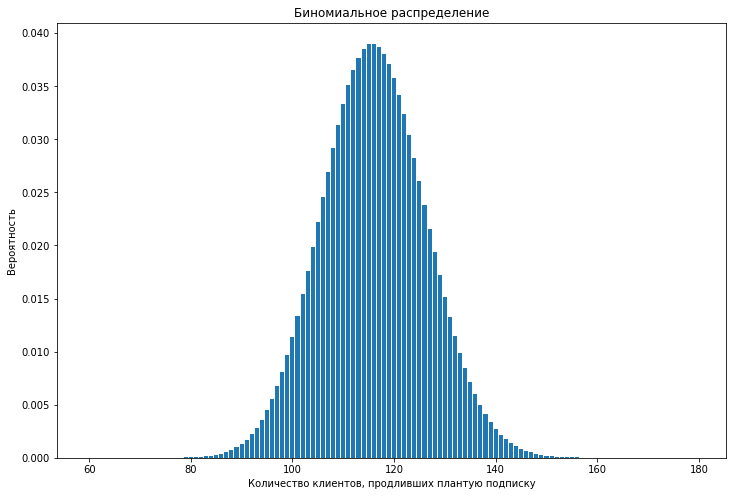

In [47]:
# График биномиального распределения
x = np.arange(60, 180)
rasp = st.binom.pmf(x, n, p)

plt.figure(figsize=(12, 8))
plt.bar(x, rasp)
plt.title('Биномиальное распределение')
plt.xlabel('Количество клиентов, продливших плантую подписку')
plt.ylabel('Вероятность')
plt.show()

Вывод: чтобы с вероятностью 95% выполнить план, нужно разослать минимум 1 161 промокод. 
_________________________________________________________

7.2 Отдел маркетинга рассылает клиентам push-уведомления в мобильном приложении. 

Клиенты могут открыть его или не открывать. 

Известно, что уведомления открывают около 40 % получивших клиентов. Отдел планирует разослать 1 млн уведомлений. 

С помощью аппроксимации постройте примерный график распределения и оцените вероятность того, что уведомление откроют не более 399,5 тыс. пользователей.
________________________________

Эта ситуация тоже описывается биномиальным распределением. Но считать каждое отдельное значение достаточно долго. Вы можете воспользоваться нормальной аппроксимацией биномиального распределения и cdf() для быстрой оценки.

In [48]:
n = 1000000  # кол-во уведомлений
p = 0.4  # вероятность что уведомление откроют (возможно два действия: открыл/не открыл)
open_push = 399500 # по условиям уведом должны открыть не более 399.5 тыс. пользователей

# Параметры нормального распределения
mu = n * p
sigma = np.sqrt((1 - p) * n * p)

rasp_open_push = st.norm.cdf(open_push, mu, sigma)
print(f'Вероятность того, что уведомление откроют не более {open_push} пользователей: {rasp_open_push:.2%}')

Вероятность того, что уведомление откроют не более 399500 пользователей: 15.37%


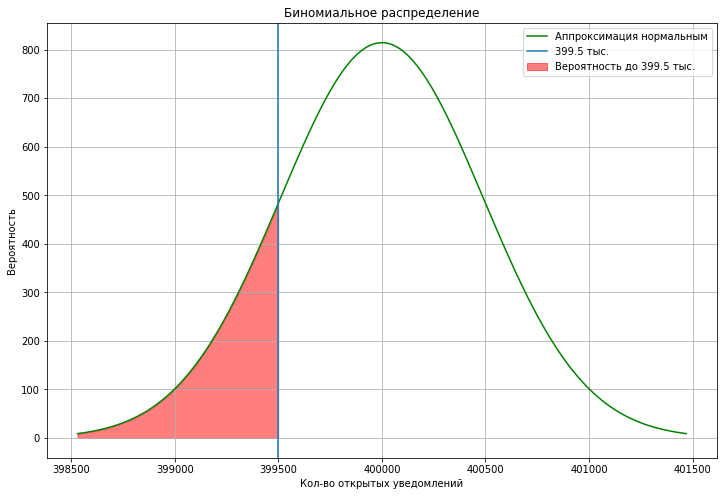

In [49]:
x_values = np.arange(mu-3*sigma, mu+3*sigma)

plt.figure(figsize=(12, 8))
plt.plot(x_values, st.norm.pdf(x_values, mu, sigma) * n, 'g-', label='Аппроксимация нормальным')


# Закрашиваем область до 399.5 тыс по х.
plt.fill_between(
    x_values, 
    st.norm.pdf(x_values, mu, sigma) * n, 
    where=(x_values <= 399500), 
    color='red', 
    alpha=0.5, 
    label='Вероятность до 399.5 тыс.'
)

# Добавляем линию для отметки 399,5 тыс.
plt.axvline(x=399500, linestyle='-', label='399.5 тыс.')

# Настройки графика
plt.title('Биномиальное распределение')
plt.xlabel('Кол-во открытых уведомлений')
plt.ylabel('Вероятность')
plt.legend()
plt.grid(True)
plt.show()

Вывод по разделу:

Мы рассчитали сколько промокодов нуждно разослать опираять на статистику предыдущей похожей акции и выяснили, что необходимо разослать минимум 1 161 промокод, чтобы с 95% вероятностью выполнить плановые показатели.

Также, опираясь на предыдущий опыт по маркетинговым акциям мы знали что уведомления открывает 40% пользователей, а мы прислали 1 млн уведомлений и ожидаем что их откроет не более 399.5 тыс. пользователей, мы статистически предсказываем вероятность что уведомления откроют столько человек оставляет 15.37%. (то есть скорее всего уведомления откроют гораздо больше пользователей и эта акция теоритечески должны быть успешной)